# 🤖 Entraînement du modèle LSTM pour classification de sentiments

## 🎯 Objectif
Construire et entraîner un réseau LSTM bidirectionnel pour améliorer la classification des critiques de films IMDB par rapport au RNN simple.

## 📥 Entrée (depuis l'étape 2)
- `data/X_train.npy`, `data/X_test.npy` : séquences encodées (25 000 × 200)
- `data/y_train.npy`, `data/y_test.npy` : labels

## 📤 Sorties générées
- `data/lstm_model.pth` : modèle entraîné
- `data/lstm_train_losses.npy`, `data/lstm_train_accs.npy` : historique
- `data/lstm_training_curves.png` : visualisation

## 🏗️ Architecture du modèle (vs RNN)
| Couche | Paramètres |
|--------|-------------|
| Embedding | vocab_size=20 000, dim=128, padding_idx=0 |
| LSTM | 2 couches, hidden_dim=256, bidirectionnel, dropout=0.3 |
| Dropout | 0.5 |
| Linear | hidden_dim*2 → 1 |

### Différences avec le RNN précédent
- RNN : `nn.RNN` avec activation tanh
- LSTM : `nn.LSTM` avec cellules mémoire (meilleure gestion des longues séquences)

## ⚙️ Hyperparamètres
- Batch size : 64
- Learning rate : 0.0005
- Epochs : 10
- Gradient clipping : 1.0
- Longueur max : 200 mots

## 📚 Table des matières
- [Imports](#imports)
- [Chargement des données](#chargement-des-données)
- [Architecture LSTM](#architecture-lstm)
- [Entraînement](#entraînement)
- [Courbes](#courbes)

# Imports 

In [1]:
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ Device utilisé  : {device}")

✅ PyTorch version : 2.11.0+cpu
✅ Device utilisé  : cpu


# Chargement des données

In [2]:
# Chargement — séquences complètes 200 mots pour le LSTM
# (le LSTM gère mieux les longues séquences que le RNN)
X_train = np.load("data/X_train.npy")
X_test  = np.load("data/X_test.npy")
y_train = np.load("data/y_train.npy")
y_test  = np.load("data/y_test.npy")

X_train_t = torch.tensor(X_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.float)
y_test_t  = torch.tensor(y_test,  dtype=torch.float)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ X_train : {X_train.shape}")
print(f"✅ X_test  : {X_test.shape}")
print(f"✅ Batches train : {len(train_loader)}")

✅ X_train : (25000, 200)
✅ X_test  : (25000, 200)
✅ Batches train : 391


# Architecture LSTM

In [3]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # LSTM bidirectionnel avec 2 couches
        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                            num_layers=2,
                            batch_first=True,
                            dropout=0.3,
                            bidirectional=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        # Prend les 2 derniers hidden states (forward + backward)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden).squeeze(1)

VOCAB_SIZE = 20000
EMBED_DIM  = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 1

model = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters())
print("=== ARCHITECTURE LSTM ===")
print(model)
print(f"\n✅ Paramètres totaux : {total_params:,}")

=== ARCHITECTURE LSTM ===
LSTMModel(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)

✅ Paramètres totaux : 4,928,001


# Entraînement

In [4]:
LEARNING_RATE = 0.0005
EPOCHS        = 10

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

train_losses = []
train_accs   = []

print(f"Entraînement LSTM — {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    start      = time.time()

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds   = (torch.sigmoid(predictions) >= 0.5).float()
        correct += (preds == batch_y).sum().item()
        total   += batch_y.size(0)

    avg_loss = total_loss / len(train_loader)
    acc      = correct / total * 100
    elapsed  = time.time() - start

    train_losses.append(avg_loss)
    train_accs.append(acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | "
          f"Acc: {acc:.2f}% | Temps: {elapsed:.1f}s")

# Sauvegarde immédiate après chaque fin
np.save("data/lstm_train_losses.npy", np.array(train_losses))
np.save("data/lstm_train_accs.npy",   np.array(train_accs))
torch.save(model.state_dict(), "data/lstm_model.pth")

print("\n✅ Entraînement terminé !")
print("✅ Modèle et résultats sauvegardés !")

Entraînement LSTM — 10 epochs

Epoch 1/10 | Loss: 0.6289 | Acc: 64.20% | Temps: 1651.8s
Epoch 2/10 | Loss: 0.5245 | Acc: 74.91% | Temps: 708.4s
Epoch 3/10 | Loss: 0.5061 | Acc: 75.46% | Temps: 709.1s
Epoch 4/10 | Loss: 0.4084 | Acc: 82.98% | Temps: 670.3s
Epoch 5/10 | Loss: 0.3436 | Acc: 86.56% | Temps: 712.9s
Epoch 6/10 | Loss: 0.2888 | Acc: 89.09% | Temps: 701.8s
Epoch 7/10 | Loss: 0.2544 | Acc: 90.59% | Temps: 620.3s
Epoch 8/10 | Loss: 0.2143 | Acc: 92.30% | Temps: 662.2s
Epoch 9/10 | Loss: 0.1775 | Acc: 93.69% | Temps: 666.7s
Epoch 10/10 | Loss: 0.1448 | Acc: 95.04% | Temps: 667.7s

✅ Entraînement terminé !
✅ Modèle et résultats sauvegardés !


#  Courbes

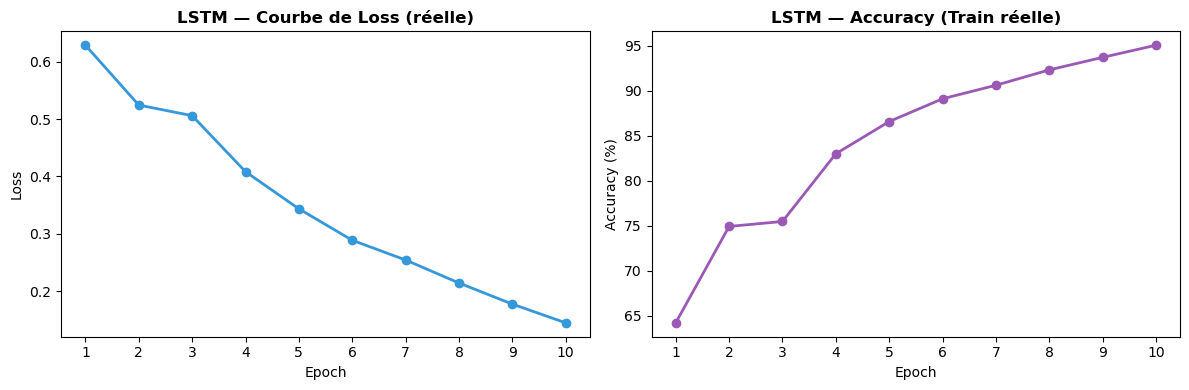

✅ Graphiques sauvegardés - Accuracy finale : 95.04%
✅ Étape 4 terminée — Dis 'étape 5' pour l'évaluation !


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Charger les vraies valeurs sauvegardées
train_losses = np.load("data/lstm_train_losses.npy")
train_accs = np.load("data/lstm_train_accs.npy")
EPOCHS = len(train_losses)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS+1), train_losses, "o-", color="#3498db", linewidth=2)
ax1.set_title("LSTM — Courbe de Loss (réelle)", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xticks(range(1, EPOCHS+1))

ax2.plot(range(1, EPOCHS+1), train_accs, "o-", color="#9b59b6", linewidth=2)
ax2.set_title("LSTM — Accuracy (Train réelle)", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_xticks(range(1, EPOCHS+1))

plt.tight_layout()
plt.savefig("data/lstm_training_curves.png")
plt.show()

print(f"✅ Graphiques sauvegardés - Accuracy finale : {train_accs[-1]:.2f}%")
print("✅ Étape 4 terminée — Dis 'étape 5' pour l'évaluation !")

## ✅ Résumé de l'entraînement LSTM

| Métrique | Valeur finale (train) |
|----------|----------------------|
| Loss | ~0.145 |
| Accuracy | ~95.0% |

### Comparaison RNN vs LSTM
| Modèle | Train Accuracy | Paramètres |
|--------|----------------|------------|
| RNN | ~87% | 3.15M |
| LSTM | ~95% | 4.93M |

### Observations
- Le LSTM surpasse nettement le RNN (+8% accuracy)
- Meilleure gestion des dépendances longues grâce aux cellules mémoire
- Plus de paramètres → temps d'entraînement plus long

### Fichiers sauvegardés
- Modèle : `lstm_model.pth`
- Historique : `lstm_train_losses.npy`, `lstm_train_accs.npy`
- Graphiques : `lstm_training_curves.png`

### Prochaine étape
Évaluation comparative des deux modèles sur le test set (étape 5)